In [ ]:
#@markdown Check type of GPU and VRAM available.
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader

Tesla T4, 15360 MiB, 15101 MiB


Кропнуть и заресайзить лица, тут можно обрабатывать сразу все https://www.birme.net/

## Подготовка данных

1. Собрать датасет от 15 изображений одно персонажа (Чем более разнооразнее и больше данных тем лучше будет качество)
2. Кропнуть и заресайзить лица, тут можно обрабатывать сразу все https://www.birme.net/



## Install Requirements

In [ ]:
!pip install peft -q

In [ ]:
!git clone https://github.com/huggingface/diffusers
%pip install git+https://github.com/huggingface/diffusers
%pip install triton
%pip install accelerate transformers ftfy gradio natsort safetensors
%pip install bitsandbytes

fatal: destination path 'diffusers' already exists and is not an empty directory.
  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-wo0yf09e
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-wo0yf09e
  Resolved https://github.com/huggingface/diffusers to commit a3cc641f78bd0c4a749e8ad03141d7fdb76eec1c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip list | grep torch

torch                              2.5.0+cu121
torchaudio                         2.5.0+cu121
torchsummary                       1.5.1
torchvision                        0.20.0+cu121


## Download model and convert model

In [ ]:
# !wget -O civitai_midel.ckpt https://civitai.com/api/download/models/201259?type=Model&format=SafeTensor&size=pruned&fp=fp16 я вручную его скачал
!wget https://raw.githubusercontent.com/CompVis/stable-diffusion/main/configs/stable-diffusion/v1-inference.yaml

--2024-11-05 09:37:57--  https://raw.githubusercontent.com/CompVis/stable-diffusion/main/configs/stable-diffusion/v1-inference.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1873 (1.8K) [text/plain]
Saving to: ‘v1-inference.yaml.1’

v1-inference.yaml.1 100%[===================>]   1.83K  --.-KB/s    in 0s      

2024-11-05 09:37:57 (26.9 MB/s) - ‘v1-inference.yaml.1’ saved [1873/1873]



In [ ]:
!python diffusers/scripts/convert_original_stable_diffusion_to_diffusers.py \
      --checkpoint_path='/content/civitai_midel.ckpt'\
      --original_config_file='/content/v1-inference.yaml'\
      --dump_path='/content/cache_dir/models/civitai_model'\
      --scheduler_type="ddim" --prediction_type='epsilon'\
      --from_safetensors

2024-11-05 09:38:01.528556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 09:38:01.548767: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 09:38:01.555038: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 09:38:03.559266: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Traceback (most recent call last):
  File "/content/diffusers/scripts/convert_original_stable_diffusion_to_diffusers.py", line 160, in <module>
    pipe = download_from_original_stable_diffusion_ckpt(
  File "/usr/local/lib/python3.10/dist-p

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Settings and run

# Start Training

Use the table below to choose the best flags based on your memory and speed requirements. Tested on Tesla T4 GPU.


| `fp16` | `train_batch_size` | `gradient_accumulation_steps` | `gradient_checkpointing` | `use_8bit_adam` | GB VRAM usage | Speed (it/s) |
| ---- | ------------------ | ----------------------------- | ----------------------- | --------------- | ---------- | ------------ |
| fp16 | 1                  | 1                             | TRUE                    | TRUE            | 9.92       | 0.93         |
| no   | 1                  | 1                             | TRUE                    | TRUE            | 10.08      | 0.42         |
| fp16 | 2                  | 1                             | TRUE                    | TRUE            | 10.4       | 0.66         |
| fp16 | 1                  | 1                             | FALSE                   | TRUE            | 11.17      | 1.14         |
| no   | 1                  | 1                             | FALSE                   | TRUE            | 11.17      | 0.49         |
| fp16 | 1                  | 2                             | TRUE                    | TRUE            | 11.56      | 1            |
| fp16 | 2                  | 1                             | FALSE                   | TRUE            | 13.67      | 0.82         |
| fp16 | 1                  | 2                             | FALSE                   | TRUE            | 13.7       | 0.83          |
| fp16 | 1                  | 1                             | TRUE                    | FALSE           | 15.79      | 0.77         |


Add `--gradient_checkpointing` flag for around 9.92 GB VRAM usage.

remove `--use_8bit_adam` flag for full precision. Requires 15.79 GB with `--gradient_checkpointing` else 17.8 GB.

remove `--train_text_encoder` flag to reduce memory usage further, degrades output quality.

In [ ]:
from huggingface_hub import snapshot_download
import os
import shutil
model_id = "stablediffusionapi/cyberrealistic-v32"
save_dir = "/content/cyberrealistic-v32"
model_dir = snapshot_download(repo_id=model_id)

os.makedirs(save_dir, exist_ok=True)
shutil.copytree(model_dir, save_dir, dirs_exist_ok=True)
os.environ['MODEL_NAME'] = save_dir

print(f"Модель сохранена в: {save_dir}")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

(…)ature_extractor/preprocessor_config.json:   0%|          | 0.00/520 [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

.gitignore:   0%|          | 0.00/15.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/492M [00:00<?, ?B/s]

vae/config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Модель сохранена в: /content/cyberrealistic-v32


In [ ]:
import os
from huggingface_hub import snapshot_download

# Устанавливаем пути для данных и результата
os.environ['INSTANCE_DIR'] = "/content/drive/MyDrive/2_semester/GAN/HW4/instance_images"
os.environ['CLASS_DIR'] = "/content/drive/MyDrive/2_semester/GAN/HW4/class_images"
os.environ['OUTPUT_DIR'] = "/content/dreambooth_output"

In [ ]:
!python3 /content/diffusers/examples/dreambooth/train_dreambooth.py \
  --pretrained_model_name_or_path=$MODEL_NAME \
  --instance_data_dir=$INSTANCE_DIR \
  --class_data_dir=$CLASS_DIR \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="a photo of sks woman face" \
  --class_prompt="a photo of woman face" \
  --with_prior_preservation --prior_loss_weight=1.0 \
  --resolution=512 \
  --train_batch_size=1 \
  --learning_rate=2e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --gradient_accumulation_steps=1 \
  --num_class_images=500 \
  --max_train_steps=800 \
  --checkpointing_steps=800 \
  --use_8bit_adam \
  --mixed_precision="no" \
  --train_text_encoder

2024-11-05 09:42:31.743195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 09:42:31.764012: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 09:42:31.771387: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 09:42:31.785502: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-05 09:42:32.931714: W tensorflow/comp

## Inference

In [ ]:
import torch
from torch import autocast
from diffusers import StableDiffusionPipeline, DDIMScheduler
from IPython.display import display
import os

model_path = "/content/dreambooth_output"

pipe = StableDiffusionPipeline.from_pretrained(model_path, safety_checker=None, torch_dtype=torch.float16).to("cuda")
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
g_cuda=None

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [ ]:
#@markdown Can set random seed here for reproducibility.
g_cuda = torch.Generator(device='cuda')
seed = 345252 #@param {type:"number"}
g_cuda.manual_seed(seed)

naked, nsfw, deformed, distorted, disfigured, poorly drawn, bad anatomy, extra limb, missing limb, floating limbs, mutated hands disconnected limbs, mutation, ugly, blurry, amputation

  0%|          | 0/35 [00:00<?, ?it/s]

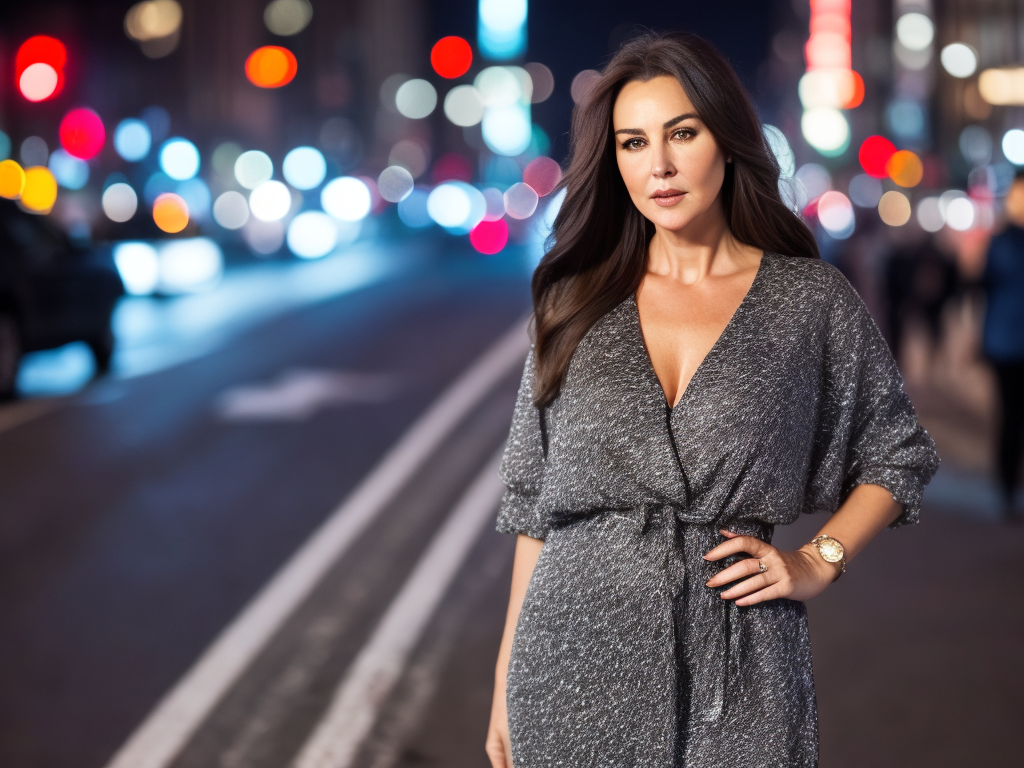

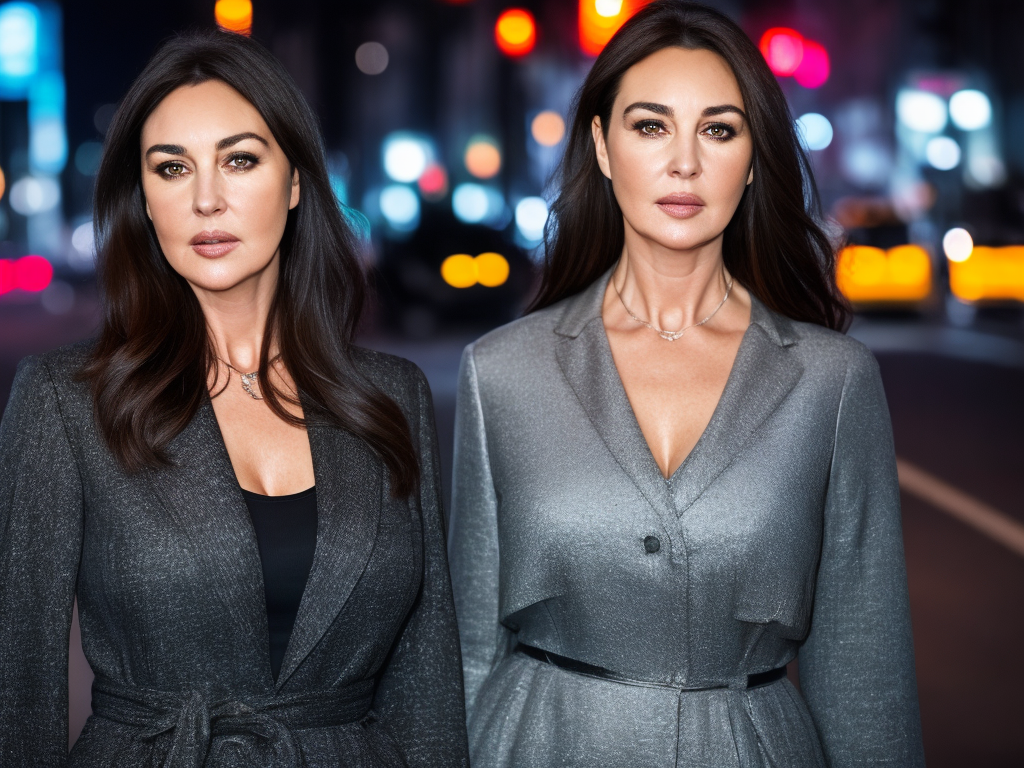

In [ ]:
#@title Run for generating images.

prompt = "portrait of sks woman face, on the street, lights, midnight, NY, standing, 4K, raw, hrd, hd, high quality, realism, sharp focus,  beautiful eyes, detailed eyes" #@param {type:"string"}
negative_prompt = "naked, nsfw, deformed, distorted, disfigured, poorly drawn, bad anatomy, extra limb, missing limb, floating limbs, mutated hands disconnected limbs, mutation, ugly, blurry, amputation" #@param {type:"string"}
num_samples = 2 #@param {type:"number"}
guidance_scale = 7.5 #@param {type:"number"}
num_inference_steps = 35 #@param {type:"number"}
height = 768 #@param {type:"number"}
width = 1024 #@param {type:"number"}

with autocast("cuda"), torch.inference_mode():
    images = pipe(
        prompt,
        height=height,
        width=width,
        negative_prompt=negative_prompt,
        num_images_per_prompt=num_samples,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=g_cuda
    ).images

for img in images:
    display(img)

In [ ]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py

--2024-11-05 10:22:12--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57591 (56K) [text/plain]
Saving to: ‘train_dreambooth_lora.py’

train_dreambooth_lo 100%[===================>]  56.24K  --.-KB/s    in 0.009s  

2024-11-05 10:22:12 (5.78 MB/s) - ‘train_dreambooth_lora.py’ saved [57591/57591]



In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
os.environ['OUTPUT_DIR'] = "/content/lora_output"

In [ ]:
!python3 /content/diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path=$MODEL_NAME \
  --instance_data_dir=$INSTANCE_DIR \
  --class_data_dir=$CLASS_DIR \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="a photo of sks woman face" \
  --class_prompt="a photo of woman face" \
  --with_prior_preservation --prior_loss_weight=1.0 \
  --resolution=512 \
  --train_batch_size=1 \
  --learning_rate=2e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --gradient_accumulation_steps=1 \
  --num_class_images=500 \
  --max_train_steps=800 \
  --checkpointing_steps=800 \
  --use_8bit_adam \
  --mixed_precision="no" \
  --train_text_encoder \
  --rank=128

2024-11-05 10:22:19.002694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 10:22:19.022476: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 10:22:19.028511: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 10:22:20.319572: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
11/05/2024 10:22:22 - INFO - __main__ - Distributed environment: NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

You are using a model of type clip_text_model to instantiate a model of type

In [ ]:
import os
import torch
from torch import autocast
from IPython.display import display
from diffusers import StableDiffusionXLPipeline, DDIMScheduler

In [ ]:
import peft
print(peft.__version__)

0.13.2


In [ ]:
from huggingface_hub import login

# Введите ваш токен доступа
login(token="")

In [ ]:
import torch
from torch import autocast
from diffusers import StableDiffusionPipeline, DDIMScheduler
from IPython.display import display
import os


model_path = "/content/dreambooth_output"

pipe = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16, safety_checker=None).to("cuda")
pipe.load_lora_weights("/content/lora_output/pytorch_lora_weights.safetensors")
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
g_cuda=None

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/35 [00:00<?, ?it/s]

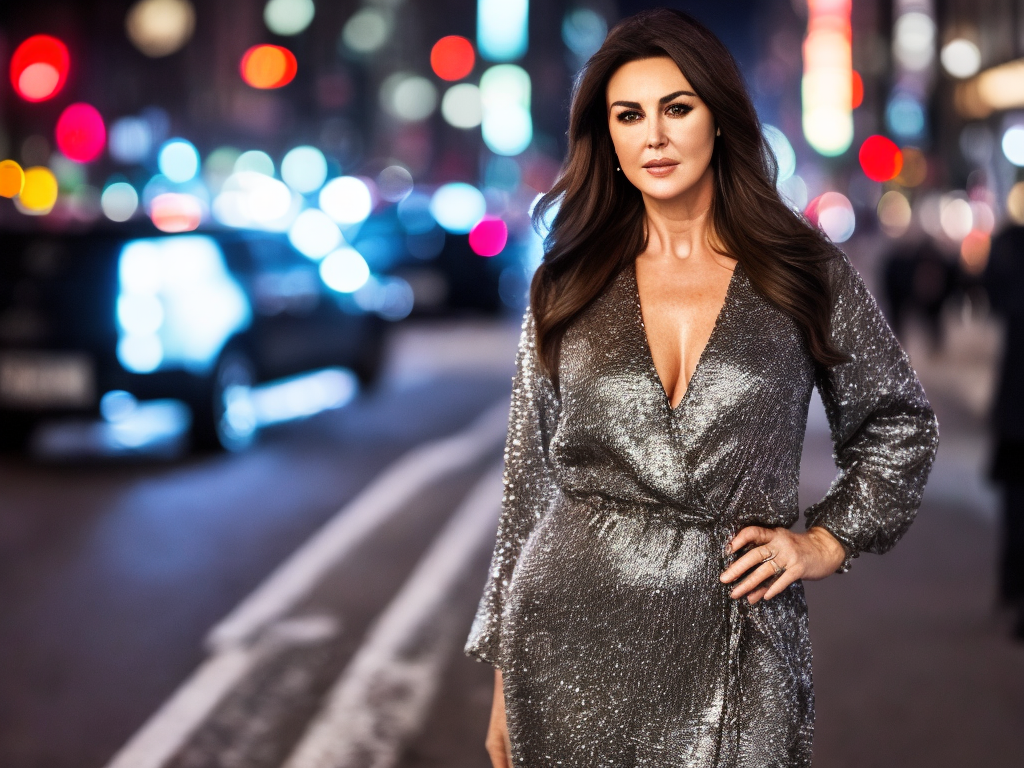

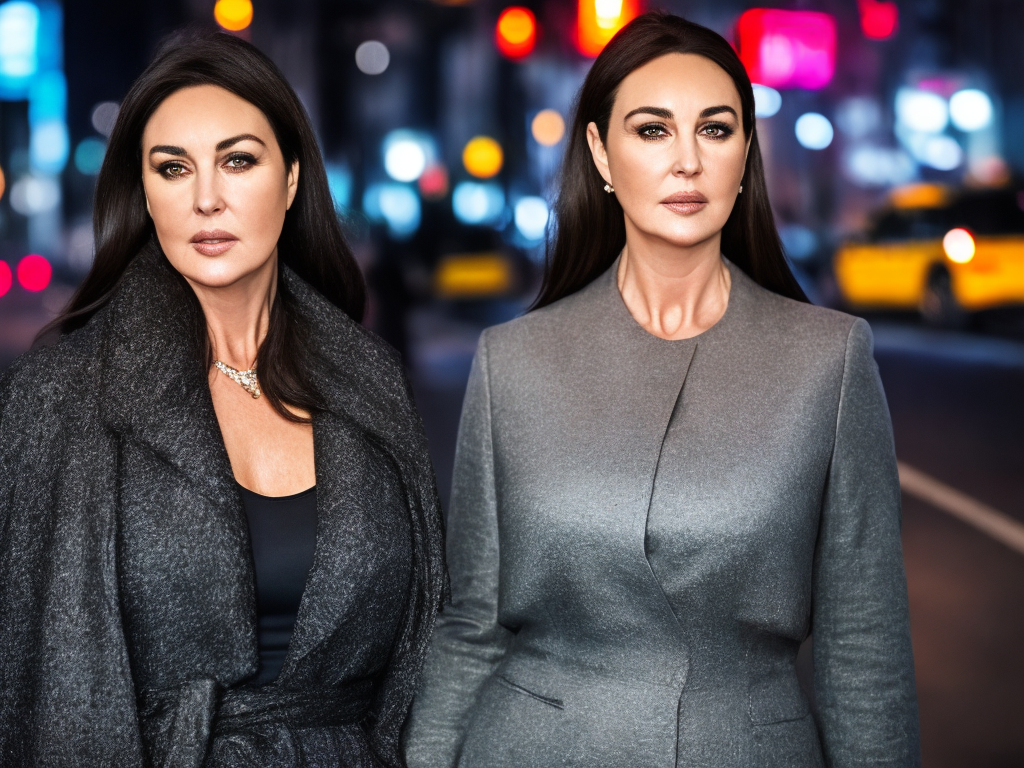

In [ ]:
prompt = "portrait of sks woman face, on the street, lights, midnight, NY, standing, 4K, raw, hrd, hd, high quality, realism, sharp focus, beautiful eyes, detailed eyes"
negative_prompt = "naked, nsfw, deformed, distorted, disfigured, poorly drawn, bad anatomy, extra limb, missing limb, floating limbs, mutated hands disconnected limbs, mutation, ugly, blurry, amputation"
num_samples = 2
guidance_scale = 7.5
num_inference_steps = 35
height = 768
width = 1024

g_cuda = torch.Generator(device='cuda')
seed = 345252
g_cuda.manual_seed(seed)

with autocast("cuda"), torch.no_grad():
    images = pipe(
        prompt,
        height=height,
        width=width,
        negative_prompt=negative_prompt,
        num_images_per_prompt=num_samples,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=g_cuda
    ).images

for img in images:
    display(img)

In [ ]:
!zip -r /content/monica_model.zip /content/lora_output

  adding: content/lora_output/ (stored 0%)
  adding: content/lora_output/checkpoint-800/ (stored 0%)
  adding: content/lora_output/checkpoint-800/optimizer.bin (deflated 15%)
  adding: content/lora_output/checkpoint-800/random_states_0.pkl (deflated 25%)
  adding: content/lora_output/checkpoint-800/pytorch_lora_weights.safetensors (deflated 7%)
  adding: content/lora_output/checkpoint-800/scheduler.bin (deflated 55%)
  adding: content/lora_output/logs/ (stored 0%)
  adding: content/lora_output/logs/dreambooth-lora/ (stored 0%)
  adding: content/lora_output/logs/dreambooth-lora/1730802165.7482328/ (stored 0%)
  adding: content/lora_output/logs/dreambooth-lora/1730802165.7482328/events.out.tfevents.1730802165.35d9bca87b47.18639.1 (deflated 56%)
  adding: content/lora_output/logs/dreambooth-lora/1730802165.7500772/ (stored 0%)
  adding: content/lora_output/logs/dreambooth-lora/1730802165.7500772/hparams.yml (deflated 53%)
  adding: content/lora_output/logs/dreambooth-lora/events.out.tfeve

## ControlNet

In [ ]:
!pip install opencv-contrib-python
!pip install controlnet_aux

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.0/510.0 kB 35.4 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.11
    Uninstalling timm-1.0.11:
      Successfully uninstalled timm-1.0.11


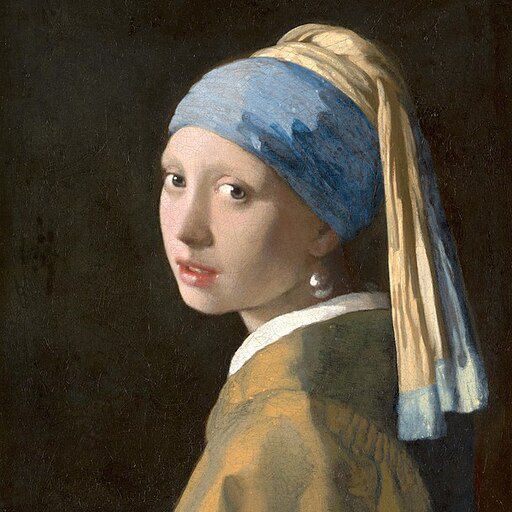

In [ ]:
from diffusers.utils import load_image

image = load_image(
    "https://hf.co/datasets/huggingface/documentation-images/resolve/main/diffusers/input_image_vermeer.png"
)
image

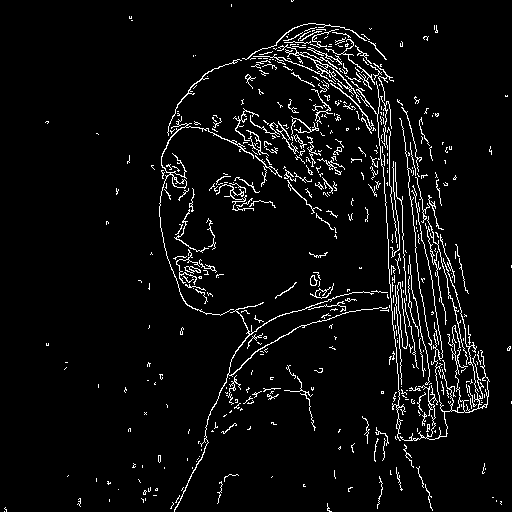

In [ ]:
import cv2
from PIL import Image
import numpy as np

image = np.array(image)

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)
canny_image

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
import torch

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import torch

model_id = "/content/dreambooth_output"
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    controlnet=controlnet,
    torch_dtype=torch.float16,
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.load_lora_weights("/content/lora_output/pytorch_lora_weights.safetensors")
pipe.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

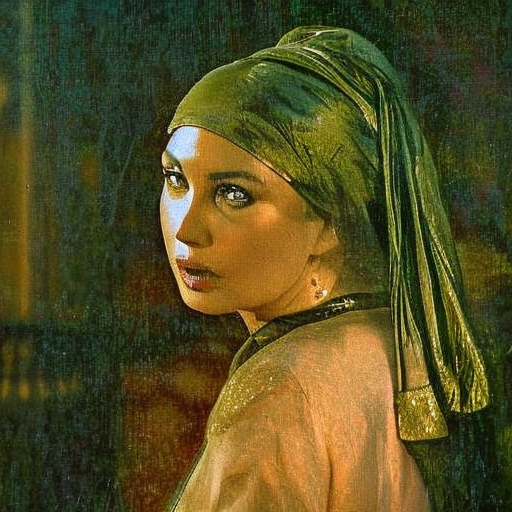

In [ ]:
generator = torch.manual_seed(2)
prompt = "a photo of sks woman face, extremely detailed, dark background, sks woman, best quality, detailed bright eyes"
output = pipe(
    prompt,
    canny_image,
    negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality, bright background",
    num_inference_steps=20,
    generator=generator,
)
output.images[0]

## Проверка в разном окружении

In [ ]:
import torch
from torch import autocast
from diffusers import StableDiffusionPipeline, DDIMScheduler
from IPython.display import display
import os

model_path = '/content/dreambooth_output'

pipe = StableDiffusionPipeline.from_pretrained(model_path, safety_checker=None, torch_dtype=torch.float16).to("cuda")
#pipe.load_lora_weights("/content/lora_output/pytorch_lora_weights.safetensors")
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
g_cuda=None
#@markdown Can set random seed here for reproducibility.
g_cuda = torch.Generator(device='cuda')
seed = 345252 #@param {type:"number"}
g_cuda.manual_seed(seed)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [ ]:
token = "a photo of sks woman face"
promt_list = [
    {
     "name": "truck",
     "prompt":f"close up portrait of {token} woman face, in the truck, sitting, 4K, raw, hrd, hd, high quality, realism, sharp focus",
     "n_prompt":"naked, nsfw, deformed, distorted, disfigured, poorly drawn, bad anatomy, extra limb, missing limb, floating limbs, mutated hands disconnected limbs, mutation, ugly, blurry, amputation",
    },
    {
     "name": "school",
     "prompt":f"portrait of {token} woman face, in the school, standing, 4K, raw, hrd, hd, high quality, realism, sharp focus",
     "n_prompt":"naked, nsfw, deformed, distorted, disfigured, poorly drawn, bad anatomy, extra limb, missing limb, floating limbs, mutated hands disconnected limbs, mutation, ugly, blurry, amputation",
    },
    {
     "name": "office",
     "prompt":f"portrait of {token} woman face, on the office, lights, midnight, NY, standing, 4K, raw, hrd, hd, high quality, realism, sharp focus,  beautiful eyes, detailed eyes",
     "n_prompt":"naked, nsfw, deformed, distorted, disfigured, poorly drawn, bad anatomy, extra limb, missing limb, floating limbs, mutated hands, mutation, ugly, blurry",
    },
]

from PIL import Image
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

In [ ]:
import os
from PIL import Image

seed = 147525234
repeat = 2
num_samples = 2
guidance_scale = 7.5
num_inference_steps = 35
height = 768
width = 1024

save_folder = "/content/generated_images/"
save_mode = "base_model"  # или "with_train_token" в зависимости от ваших нужд

for idx, sample in enumerate(promt_list):
    prompt = sample.get("prompt")
    negative_prompt = sample.get("n_prompt")
    name = sample.get("name")
    image_list = []

    for _ in range(repeat):
        generator = torch.Generator("cuda").manual_seed(seed)
        with autocast("cuda"), torch.inference_mode():
            images = pipe(
                prompt,
                height=height,
                width=width,
                negative_prompt=negative_prompt,
                num_images_per_prompt=num_samples,
                num_inference_steps=num_inference_steps,
                guidance_scale=guidance_scale,
                generator=generator
            ).images
        image_list.extend(images)
        seed += 345324

    img_grid = image_grid(image_list, num_samples, repeat)
    save_path = os.path.join(save_folder, save_mode, f"{height}x{width}")
    os.makedirs(save_path, exist_ok=True)
    img_grid.save(os.path.join(save_path, f"{name}.jpg"))

# Отобразим путь к сохраненным файлам
print(f"Images saved at: {save_folder}")

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Images saved at: /content/generated_images/
